# Tutorial 10 — Symmetry, Group Actions, and Equivariant Models

**MM845 — Tópicos de Geometria III: AI for Geometry**
Paired with **Lecture 10: Geometry-Aware ML I — Equivariance and Symmetry**

---

This tutorial makes explicit a theme that has appeared in every practical session so
far. Tutorial 2 split data by orbit rather than by sample. Tutorial 3 found that
rotation-invariant features turned a hopeless regression into an exact one. Tutorial
5 watched a CNN survive translations that destroyed an MLP. Tutorial 6 did the same
for permutations.

Lecture 10 gives the general statement. A group $G$ acts on the data; the label is
invariant, $y(g\cdot x) = y(x)$; and there are exactly **three** ways to build a model
that respects that:

| strategy | how | cost |
|---|---|---|
| **augment** | show the model $g\cdot x$ during training | samples, capacity, and only approximate |
| **canonicalise / invariant features** | map $x$ to a $G$-invariant descriptor first | must find the invariants; may lose information |
| **equivariant architecture** | build layers that commute with $G$ | exact by construction; constrains the design |

We compare all three on the same data, against the same budget, and measure what
each is worth.

| § | Question |
|---|---|
| 1 | A dataset with an exact $SO(3)$ symmetry |
| 2 | Three strategies, one comparison |
| 3 | Sample efficiency: the real currency |
| 4 | A different group: $S_n$ acting on graphs |
| 5 | Summary |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

SEED = 20260930
rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)

GEO_DARK, GEO_TEAL, GEO_RUST = "#103158", "#006c86", "#b2461e"
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.titlesize": 10,
                     "axes.grid": True, "grid.alpha": 0.25,
                     "axes.prop_cycle": plt.cycler(color=[GEO_DARK, GEO_TEAL, GEO_RUST])})
print("torch", torch.__version__)

torch 2.13.0+cpu


---
## 1. A dataset carrying an exact group action

Each sample is a small point cloud in $\mathbb{R}^3$ drawn from a random ellipsoid
with semi-axes $(a,b,c)$. The label is the **volume** $\tfrac43\pi abc$ of that
ellipsoid — a quantity determined by the shape and manifestly unchanged if we rotate
the whole cloud.

So $G = SO(3)$ acts on the inputs, and the label is exactly $G$-invariant. That is
the setting Lecture 10 formalises, and it lets us measure the three strategies against
a ground truth we control.

We use unit quaternions to generate Haar-uniform rotations, exactly as in Tutorial 2
§4 — a reminder that "a uniformly random rotation" is a sampling problem on $S^3$.

In [2]:
N_PTS = 24


def quat_to_rotation(q):
    w, x, y, z = q
    return np.array([
        [1 - 2 * (y * y + z * z), 2 * (x * y - w * z), 2 * (x * z + w * y)],
        [2 * (x * y + w * z), 1 - 2 * (x * x + z * z), 2 * (y * z - w * x)],
        [2 * (x * z - w * y), 2 * (y * z + w * x), 1 - 2 * (x * x + y * y)]])


def random_rotation(rng):
    q = rng.normal(size=4)
    return quat_to_rotation(q / np.linalg.norm(q))


def make_clouds(n, rng, rotate=True, n_pts=N_PTS):
    """Point clouds on random ellipsoids, labelled by ellipsoid volume."""
    axes_ = rng.uniform(0.4, 1.2, size=(n, 3))
    v = rng.normal(size=(n, n_pts, 3))
    v /= np.linalg.norm(v, axis=-1, keepdims=True)
    X = v * axes_[:, None, :]
    if rotate:
        X = np.stack([c @ random_rotation(rng).T for c in X])
    vol = 4 / 3 * np.pi * np.prod(axes_, axis=1)
    return X.astype(np.float32), vol.astype(np.float32)


# training clouds are all in a CANONICAL orientation (axis-aligned);
# the test set is rotated, which is the distribution shift we care about
Xtr, ytr = make_clouds(4000, rng, rotate=False)
Xte, yte = make_clouds(1200, rng, rotate=False)
Xte_rot, yte_rot = make_clouds(1200, np.random.default_rng(7), rotate=True)

print(f"clouds {Xtr.shape},  volume in [{ytr.min():.2f}, {ytr.max():.2f}]")
print(f"predict-the-mean baseline MSE: {np.mean((yte - ytr.mean())**2):.4f}")

R = random_rotation(rng)
print(f"\nlabel invariance is exact by construction; check the Gram matrix instead:")
G0 = Xte[0] @ Xte[0].T
G1 = (Xte[0] @ R.T) @ (Xte[0] @ R.T).T
print(f"   ||G(X) - G(XR^T)||_inf = {np.abs(G0 - G1).max():.2e}")

clouds (4000, 24, 3),  volume in [0.34, 6.63]
predict-the-mean baseline MSE: 1.1702

label invariance is exact by construction; check the Gram matrix instead:
   ||G(X) - G(XR^T)||_inf = 4.02e-08


The last line is the key to strategy two. The **Gram matrix** $G = XX^\top$ of a point
cloud is exactly $SO(3)$-invariant, since $(XR^\top)(XR^\top)^\top = XR^\top R X^\top = XX^\top$.
It is also *complete* for this action: two clouds have the same Gram matrix precisely
when they differ by an orthogonal transformation. So invariant descriptors built from
$G$ lose nothing except the orientation, which is exactly what we want to discard.

---
## 2. Three strategies

- **Raw.** An MLP on the flattened $24 \times 3$ coordinates. Knows nothing.
- **Augmented.** The same MLP, but each training cloud is randomly rotated afresh
  every epoch. This is the standard practical fix.
- **Equivariant.** A network whose layers *commute* with the action: it maps the cloud
  to a stack of vectors that rotate along with it, and takes norms only at the very
  end. Exactly invariant by construction, and it is never shown an invariant we
  derived by hand.
- **Invariant.** An MLP on a $G$-invariant descriptor: the sorted eigenvalues of the
  covariance $X^\top X$. For an ellipsoid cloud these are essentially $a^2, b^2, c^2$,
  so the descriptor is short, complete for our purposes, and exactly invariant.

All four use the same hidden width and the same number of epochs.

In [3]:
def invariant_features(X):
    """Sorted eigenvalues of the covariance: an exact SO(3) invariant."""
    C = np.einsum("nki,nkj->nij", X, X) / X.shape[1]
    ev = np.linalg.eigvalsh(C)                    # ascending, hence canonical
    return np.sqrt(np.maximum(ev, 0)).astype(np.float32)


def mlp(d_in, width=128):
    return nn.Sequential(nn.Linear(d_in, width), nn.ReLU(),
                         nn.Linear(width, width), nn.ReLU(),
                         nn.Linear(width, 1))


def train(model, X, y, epochs=60, bs=256, lr=3e-3, augment=False, rng=None):
    yt = torch.tensor(y).unsqueeze(1)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    lossf = nn.MSELoss()
    for ep in range(epochs):
        if augment:                               # a fresh rotation every epoch
            Xe = np.stack([c @ random_rotation(rng).T for c in X]).astype(np.float32)
        else:
            Xe = X
        Xt = torch.tensor(Xe.reshape(len(Xe), -1) if Xe.ndim == 3 else Xe)
        perm = torch.randperm(len(Xt))
        for i in range(0, len(Xt), bs):
            idx = perm[i:i + bs]
            opt.zero_grad(); lossf(model(Xt[idx]), yt[idx]).backward(); opt.step()
    return model


def mse(model, X, y):
    Xf = X.reshape(len(X), -1) if X.ndim == 3 else X
    with torch.no_grad():
        return float(np.mean((model(torch.tensor(Xf)).numpy().ravel() - y)**2))


nparams = lambda m: sum(p.numel() for p in m.parameters())
Ftr, Fte, Fte_rot = (invariant_features(A) for A in (Xtr, Xte, Xte_rot))
print("invariant descriptor shape:", Ftr.shape)

# same cloud, actually rotated by R -- this is the real invariance check
f0 = invariant_features(Xte[0:1])[0]
f0_rot = invariant_features((Xte[0] @ R.T)[None])[0]
print(f"same cloud invariance: |f(X) - f(XR^T)| = {np.abs(f0 - f0_rot).max():.2e}")
print(f"  f(X)    = {f0.round(5)}")
print(f"  f(XR^T) = {f0_rot.round(5)}")

invariant descriptor shape: (4000, 3)
same cloud invariance: |f(X) - f(XR^T)| = 2.98e-08
  f(X)    = [0.25978 0.35581 0.46833]
  f(XR^T) = [0.25978 0.35581 0.46833]


**The equivariant architecture.** `EquivariantNet` replaces the flattened $72$-vector
with a single linear layer $W \in \mathbb{R}^{c\times 24}$ that mixes the $24$ *points*
into $c$ new "virtual points," while never touching the $3$ coordinates: $V = WX$. A
rotation acts on the coordinate side, $X \mapsto XR^\top$, so it commutes with $W$ by
associativity alone, $W(XR^\top) = (WX)R^\top$ — the hidden vectors rotate along with
the cloud instead of being scrambled by it. Taking the norm $\lVert v_k\rVert$ of each
of the $c$ vectors then gives an exactly rotation-invariant descriptor, since
orthogonal matrices preserve length, and only *that* is passed to the final `mlp()`.

This is the key difference from a raw MLP on the flattened coordinates: a plain
`nn.Linear(72, width)` mixes points and coordinates together indiscriminately, so
nothing stops it from learning a rule that depends on orientation, and rotation
invariance (if it appears at all) can only be approximate and learned from data. Here
it is built into the layer structure itself — true for every rotation, including ones
never seen in training, and true before a single gradient step is taken.


In [4]:
class EquivariantNet(nn.Module):
    """One SO(3)-equivariant layer, an invariant readout, then the same mlp() as above.

    A rotation acts on the right, X -> X R^T, so a linear map W on the *point* index
    commutes with it:  W (X R^T) = (W X) R^T.  The hidden state V = W X is therefore
    a stack of c vectors that rotate along with the cloud -- equivariant, not yet
    invariant -- and the norms |V_k| are the first invariant one can write down.
    """

    def __init__(self, c=64, width=128):
        super().__init__()
        self.W = nn.Linear(N_PTS, c, bias=False)     # mixes points, never coordinates
        self.head = mlp(c, width)

    def vectors(self, Xflat):                        # (B, 72) -> (B, c, 3)
        V = Xflat.view(-1, N_PTS, 3)
        return self.W(V.transpose(1, 2)).transpose(1, 2)

    def forward(self, Xflat):
        return self.head(self.vectors(Xflat).norm(dim=-1))


# equivariance is a property of the architecture, not of training: check it untrained
probe = EquivariantNet()
Xb = torch.tensor(Xte[:8].reshape(8, -1))
Xb_rot = torch.tensor((Xte[:8] @ R.T).reshape(8, -1).astype(np.float32))
with torch.no_grad():
    V, V_rot = probe.vectors(Xb), probe.vectors(Xb_rot)
    print(f"hidden layer equivariant: max|f(XR^T) - f(X)R^T| = "
          f"{(V_rot - V @ torch.tensor(R.T, dtype=torch.float32)).abs().max():.2e}"
          f"   (features of size {V.abs().max():.2f})")
    print(f"output invariant:         max|F(XR^T) - F(X)|    = "
          f"{(probe(Xb_rot) - probe(Xb)).abs().max():.2e}")

hidden layer equivariant: max|f(XR^T) - f(X)R^T| = 2.38e-07   (features of size 0.97)
output invariant:         max|F(XR^T) - F(X)|    = 2.98e-08


In [5]:
torch.manual_seed(0); m_raw = train(mlp(3 * N_PTS), Xtr, ytr)
torch.manual_seed(0); m_aug = train(mlp(3 * N_PTS), Xtr, ytr, augment=True,
                                    rng=np.random.default_rng(1))
torch.manual_seed(0); m_eqv = train(EquivariantNet(), Xtr, ytr)
torch.manual_seed(0); m_inv = train(mlp(3), Ftr, ytr)

base = np.mean((yte - ytr.mean())**2)
rows = [("raw MLP", m_raw, mse(m_raw, Xte, yte), mse(m_raw, Xte_rot, yte_rot)),
        ("+ augmentation", m_aug, mse(m_aug, Xte, yte), mse(m_aug, Xte_rot, yte_rot)),
        ("equivariant net", m_eqv, mse(m_eqv, Xte, yte), mse(m_eqv, Xte_rot, yte_rot)),
        ("invariant features", m_inv, mse(m_inv, Fte, yte), mse(m_inv, Fte_rot, yte_rot))]

print(f"predict-the-mean baseline MSE {base:.4f}\n")
print(f"  {'model':20s} {'params':>8s} {'canonical':>11s} {'rotated':>10s}")
for name, m, a, b in rows:
    print(f"  {name:20s} {nparams(m):8,d} {a:11.5f} {b:10.5f}")


def gram_feats(X):
    """The whole Gram matrix XX^T: exactly invariant AND complete -- but unreduced."""
    G = np.einsum("nik,njk->nij", X, X)
    iu = np.triu_indices(X.shape[1])
    return G[:, iu[0], iu[1]].astype(np.float32)


Gtr, Gte, Gte_rot = (gram_feats(A) for A in (Xtr, Xte, Xte_rot))
torch.manual_seed(0); m_gram = train(mlp(Gtr.shape[1]), Gtr, ytr)
print(f"\n  for contrast, the same MLP on the complete invariant in raw form:")
print(f"  {'Gram matrix XX^T':20s} {nparams(m_gram):8,d} "
      f"{mse(m_gram, Gte, yte):11.5f} {mse(m_gram, Gte_rot, yte_rot):10.5f}")

predict-the-mean baseline MSE 1.1702

  model                  params   canonical    rotated
  raw MLP                25,985     0.33265    0.33423
  + augmentation         25,985     0.22490    0.22261
  equivariant net        26,497     0.10303    0.10133
  invariant features     17,153     0.01102    0.01170

  for contrast, the same MLP on the complete invariant in raw form:
  Gram matrix XX^T       55,169     0.45853    0.44118


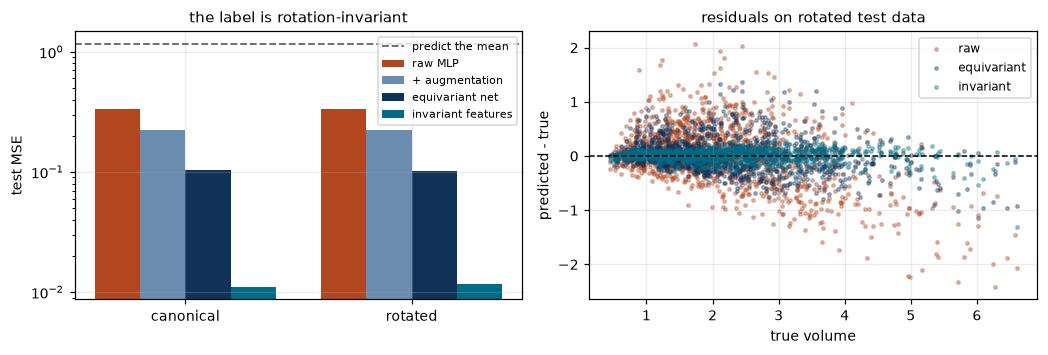

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.3))
w = 0.2
cols = [GEO_RUST, "#6a8caf", GEO_DARK, GEO_TEAL]
for k, (name, _, a, b) in enumerate(rows):
    axes[0].bar(np.arange(2) + (k - 1.5) * w, [a, b], w, label=name, color=cols[k])
axes[0].axhline(base, color="0.4", ls="--", lw=1.2, label="predict the mean")
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(["canonical", "rotated"])
axes[0].set_yscale("log"); axes[0].set_ylabel("test MSE")
axes[0].set_title("the label is rotation-invariant"); axes[0].legend(fontsize=7)

with torch.no_grad():
    Xf_rot = torch.tensor(Xte_rot.reshape(len(Xte_rot), -1))
    preds = [("raw", m_raw(Xf_rot).numpy().ravel(), GEO_RUST),
             ("equivariant", m_eqv(Xf_rot).numpy().ravel(), GEO_DARK),
             ("invariant", m_inv(torch.tensor(Fte_rot)).numpy().ravel(), GEO_TEAL)]
axes[1].axhline(0, color="k", ls="--", lw=1)
for name, p, col in preds:            # widest spread first, so the tightest sits on top
    axes[1].scatter(yte_rot, p - yte_rot, s=5, alpha=0.35, color=col, label=name)
axes[1].set_xlabel("true volume"); axes[1].set_ylabel("predicted - true")
axes[1].set_title("residuals on rotated test data"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

The numbers do not tell the story you might expect from Tutorials 5 and 6, and the
difference is worth understanding.

The raw model does **not** collapse under rotation — it scores about the same on
both test sets. But look at what that score is: roughly a third of the
predict-the-mean baseline, which is to say it barely learned the task in the first
place. There was no sharp orientation-dependent rule for rotation to break, because
the model never found a good rule at all. Its problem is not brittleness; it is that
it is spending a 26,000-parameter budget on a $72$-dimensional input in which the
points arrive in arbitrary order and the relevant quantity — three principal
semi-axes — is buried.

Augmentation helps, by roughly a third. The **equivariant** net, on the same raw
coordinates and within two per cent of the same parameter budget, is three times
better than the raw model and twice as good as augmentation — and where augmentation
is approximately invariant to the rotations it happened to be shown, this one is
invariant to machine precision, on all of them, before it has been trained at all.
The **invariant** model is better again by a further factor of eight, on a
three-dimensional input.

The last line of the table is there to stop an easy misreading. Give the same MLP the
*complete* invariant — the whole Gram matrix $XX^\top$, $300$ numbers from which the
cloud is determined up to rotation — and it does **worse than the raw coordinates**.
Nothing has been lost to the group; everything is still there. What is missing is
that no linear-plus-ReLU stack of this size extracts three eigenvalues from a $24
\times 24$ Gram matrix. `eigvalsh` is doing hard nonlinear work, and the
fortyfold gap between the last two rows of the table measures that work, not the
symmetry.

Four observations, all of which Lecture 10 emphasises.

- **Symmetry is not only about robustness; it is about difficulty.** Quotienting by
  the group shrinks the problem. Here it turned a $72$-dimensional regression that a
  large network could not do well into a $3$-dimensional one that a small network
  does almost perfectly.
- **Augmentation buys approximate invariance at a price.** The model must spend
  capacity representing the orbit, it is only invariant to what it was shown, and it
  converges more slowly because the effective training distribution is larger.
- **An equivariant architecture buys exactness, not feature extraction.** It removes
  the orbit from the hypothesis space for free, which is worth a factor of three
  here — but it will not do your nonlinear algebra for you, which is why three
  hand-computed eigenvalues still beat it.
- **Invariance is free if you know the invariants.** The eigenvalues of $X^\top X$ are
  a complete invariant for the $O(3)$ action, so nothing about the *shape* is lost.
  This is the best case, and reaching it requires mathematics rather than compute —
  which is precisely this audience's comparative advantage.

One honest caveat about our equivariant net, and it is the bridge to §4. It commutes
with rotations, but its layer $W$ mixes the $24$ points with fixed weights, so it is
*not* equivariant to reordering them — even though the points of each cloud arrive in
a meaningless order. The raw MLP carries exactly the same handicap, so the comparison
above is fair; but a second group is acting here and no model in this section
respects it. Section 4 takes that second group seriously.

> **Exercise 1 — when the invariants are incomplete.**
> (a) Replace the eigenvalue descriptor by a deliberately lossy one — say, only the
> largest eigenvalue. Measure how much accuracy you lose, and relate it to what the
> descriptor cannot see.
>
> (b) Change the label to something *not* rotation-invariant, e.g. the height of the
> topmost point. Now the invariant model must fail. Confirm it, and say precisely
> which of the three strategies is appropriate.
>
> (c) The eigenvalues are invariant under the full $O(3)$, including reflections. Find
> a label that distinguishes a cloud from its mirror image (chirality) and show that
> this descriptor cannot represent it. What would you have to add?
>
> (d) Make `EquivariantNet` permutation-equivariant too, by pooling over points
> instead of mixing them with a fixed $W$. Does respecting the second group help, and
> if not, why not?

---
## 3. Sample efficiency is the real currency

Comparing final accuracies at a fixed dataset size understates the difference. The
claim in Lecture 10 is stronger: a model that already respects the symmetry needs
**fewer examples**, because it does not have to learn the symmetry from data.

That is a claim about learning *curves*, so we measure learning curves.

In [7]:
sizes = [100, 250, 600, 1500, 4000]
curves = {"raw MLP": [], "+ augmentation": [], "invariant features": []}
for n in sizes:
    Xs, ys = Xtr[:n], ytr[:n]
    Fs = Ftr[:n]
    torch.manual_seed(0); a = train(mlp(3 * N_PTS), Xs, ys, epochs=80)
    torch.manual_seed(0); b = train(mlp(3 * N_PTS), Xs, ys, epochs=80, augment=True,
                                    rng=np.random.default_rng(2))
    torch.manual_seed(0); c = train(mlp(3), Fs, ys, epochs=80)
    curves["raw MLP"].append(mse(a, Xte_rot, yte_rot))
    curves["+ augmentation"].append(mse(b, Xte_rot, yte_rot))
    curves["invariant features"].append(mse(c, Fte_rot, yte_rot))

print(f"  {'N':>6s} " + " ".join(f"{k:>20s}" for k in curves))
for i, n in enumerate(sizes):
    print(f"  {n:6d} " + " ".join(f"{curves[k][i]:20.5f}" for k in curves))

       N              raw MLP       + augmentation   invariant features
     100              0.94526              0.69810              0.29536
     250              0.89148              0.66327              0.10290
     600              0.71656              0.44530              0.01792
    1500              0.51541              0.30891              0.01303
    4000              0.33268              0.20648              0.01093


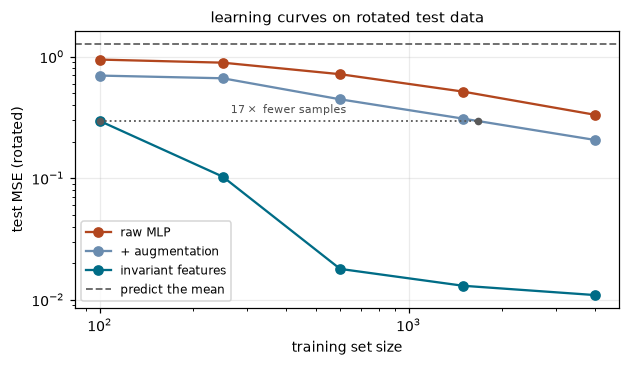

invariant model at N=100:              MSE 0.29536
augmented model matches it at N ~ 1673:   a 17-fold saving in data
augmented model at N=4000, for reference: MSE 0.20648


In [8]:
# how much data does augmentation need to reach what invariance gets at N = 100?
# read it off the curve by interpolation, not off the axis by dividing endpoints
n_inv, n_aug = curves["invariant features"], curves["+ augmentation"]
target = n_inv[0]
n_equiv = float(np.exp(np.interp(np.log(target),
                                 np.log(n_aug)[::-1], np.log(sizes)[::-1])))

fig, ax = plt.subplots(figsize=(5.8, 3.4))
for (name, ys_), col in zip(curves.items(), [GEO_RUST, "#6a8caf", GEO_TEAL]):
    ax.loglog(sizes, ys_, "o-", color=col, label=name)
ax.axhline(np.mean((yte_rot - ytr.mean())**2), color="0.4", ls="--", lw=1.2,
           label="predict the mean")
ax.plot([sizes[0], n_equiv], [target, target], ":o", color="0.35", lw=1.2, ms=4)
ax.annotate(rf"${n_equiv / sizes[0]:.0f}\times$ fewer samples",
            xy=(np.sqrt(sizes[0] * n_equiv), target), xytext=(0, 5),
            textcoords="offset points", ha="center", fontsize=7.5, color="0.3")
ax.set_xlabel("training set size"); ax.set_ylabel("test MSE (rotated)")
ax.set_title("learning curves on rotated test data"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"invariant model at N={sizes[0]}:              MSE {target:.5f}")
print(f"augmented model matches it at N ~ {n_equiv:>4.0f}:   "
      f"a {n_equiv / sizes[0]:.0f}-fold saving in data")
print(f"augmented model at N={sizes[-1]}, for reference: MSE {n_aug[-1]:.5f}")

The invariant model is better at every training-set size, and the gap is widest at
the small end. A learning curve is read **horizontally**: the question is not which
curve is lower at a given $N$, but how far right you must travel to buy the same
accuracy. The augmented model needs about **1700** clouds to reach what the invariant
model reaches with **100** — a **seventeenfold** saving in data, bought with one
linear-algebra observation.

The dotted segment in the figure is that reading. It is an interpolation between
measured points, so take it as an order of magnitude rather than a constant; the order
of magnitude is the claim. Note in particular that the saving is *not* $4000/100$:
augmentation does keep improving, and by $N = 4000$ it has passed the level the
invariant model held at $N = 100$.

For this course the point is sharper than usual. Generating mathematical data is
cheap (Lecture 2 said so), but *interesting* mathematical data often is not: computing
an invariant of a variety, a homology group, or a Ricci-flat metric can be expensive
enough that the size of your dataset is set by your compute budget. Symmetry is then
the cheapest way to buy effective samples, and it costs only the effort of working out
what the invariants are.

---
## 4. A different group: permutations acting on graphs

The framework is not about rotations. Take $G = S_n$ acting on graphs by relabelling
vertices — the adjacency matrix transforms as $A \mapsto PAP^\top$ — and a label that
does not care, such as the number of triangles $\tfrac16\operatorname{tr}(A^3)$.

The same three strategies apply. The invariant one now uses **spectral**
descriptors: the eigenvalues of $A$ are unchanged by conjugation with a permutation
matrix, which is the same idea as §2 with a different group. The equivariant one is
now the famous case — **message passing** — and it takes about a dozen lines.

In [9]:
N_NODES = 12


def make_graphs(n, rng, permute=False):
    p = rng.uniform(0.15, 0.55, size=n)
    A = (rng.random((n, N_NODES, N_NODES)) < p[:, None, None]).astype(np.float32)
    A = np.triu(A, 1)
    A = A + np.transpose(A, (0, 2, 1))
    if permute:
        out = np.empty_like(A)
        for i in range(n):
            q = rng.permutation(N_NODES)
            out[i] = A[i][np.ix_(q, q)]
        A = out
    tri = np.trace(A @ A @ A, axis1=1, axis2=2) / 6.0
    return A, tri.astype(np.float32)


def spectral_features(A):
    return np.sort(np.linalg.eigvalsh(A), axis=1).astype(np.float32)


Atr, ttr = make_graphs(4000, rng)
Ate, tte = make_graphs(1200, rng)
Ate_p, tte_p = make_graphs(1200, np.random.default_rng(11), permute=True)

print(f"triangle counts in [{ttr.min():.0f}, {ttr.max():.0f}], "
      f"baseline MSE {np.mean((tte - ttr.mean())**2):.3f}")

A0 = Ate[0]; q = np.random.default_rng(0).permutation(N_NODES)
print(f"spectrum invariance: max|eig(A) - eig(PAP^T)| = "
      f"{np.abs(np.sort(np.linalg.eigvalsh(A0)) - np.sort(np.linalg.eigvalsh(A0[np.ix_(q,q)]))).max():.2e}")

triangle counts in [0, 87], baseline MSE 140.576
spectrum invariance: max|eig(A) - eig(PAP^T)| = 3.71e-16


In [10]:
flat = lambda A: A.reshape(len(A), -1)


class MessagePassing(nn.Module):
    """h_i <- phi(h_i, sum_{j~i} h_j) for a few rounds, then sum over the nodes.

    Relabelling sends A -> P A P^T, and (P A P^T)(P h) = P (A h), so every round
    carries the permutation along unchanged: h -> P h.  Summing over nodes at the end
    is a symmetric function of them, hence exactly S_n-invariant.
    """

    def __init__(self, width=32, rounds=3):
        super().__init__()
        self.embed = nn.Linear(1, width)
        self.msg = nn.ModuleList([nn.Linear(2 * width, width) for _ in range(rounds)])
        self.head = mlp(width)

    def nodes(self, Aflat):                          # (B, 144) -> (B, 12, width)
        A = Aflat.view(-1, N_NODES, N_NODES)
        h = self.embed(torch.ones(A.shape[0], N_NODES, 1))
        for lin in self.msg:
            h = torch.relu(lin(torch.cat([h, A @ h], -1)))
        return h

    def forward(self, Aflat):
        return self.head(self.nodes(Aflat).sum(1))


# relabel the SAME graphs, so this is invariance and not a second sample
probe_g = MessagePassing()
qq = np.random.default_rng(0).permutation(N_NODES)
Ab, Ab_perm = Ate[:8], Ate[:8][:, qq][:, :, qq]
with torch.no_grad():
    hb = probe_g.nodes(torch.tensor(flat(Ab)))
    hq = probe_g.nodes(torch.tensor(flat(Ab_perm)))
    print(f"node features equivariant: max|h(PAP^T) - P h(A)| = "
          f"{(hq - hb[:, qq]).abs().max():.2e}")
    print(f"prediction invariant:      max|F(PAP^T) - F(A)|   = "
          f"{(probe_g(torch.tensor(flat(Ab_perm))) - probe_g(torch.tensor(flat(Ab)))).abs().max():.2e}")

node features equivariant: max|h(PAP^T) - P h(A)| = 3.81e-06
prediction invariant:      max|F(PAP^T) - F(A)|   = 9.54e-07


In [11]:
torch.manual_seed(0); g_raw = train(mlp(N_NODES * N_NODES), flat(Atr), ttr, epochs=80)
torch.manual_seed(0); g_mp = train(MessagePassing(), flat(Atr), ttr, epochs=80)
torch.manual_seed(0); g_spec = train(mlp(N_NODES), spectral_features(Atr), ttr, epochs=80)

base_g = np.mean((tte - ttr.mean())**2)
print(f"predict-the-mean baseline MSE {base_g:.3f}\n")
print(f"  {'model':22s} {'params':>8s} {'as generated':>14s} {'permuted':>11s}")
print(f"  {'raw MLP on A':22s} {nparams(g_raw):8,d} "
      f"{mse(g_raw, flat(Ate), tte):14.3f} {mse(g_raw, flat(Ate_p), tte_p):11.3f}")
print(f"  {'message passing':22s} {nparams(g_mp):8,d} "
      f"{mse(g_mp, flat(Ate), tte):14.3f} {mse(g_mp, flat(Ate_p), tte_p):11.3f}")
print(f"  {'spectrum of A':22s} {nparams(g_spec):8,d} "
      f"{mse(g_spec, spectral_features(Ate), tte):14.3f} "
      f"{mse(g_spec, spectral_features(Ate_p), tte_p):11.3f}")

predict-the-mean baseline MSE 140.576

  model                    params   as generated    permuted
  raw MLP on A             35,201          4.305       4.704
  message passing          27,169          1.851       1.743
  spectrum of A            18,305          0.288       0.272


  pair                       triangles   spectra differ   embeddings differ
  C_6  vs  C_3 + C_3            0 vs 2         1.00e+00            0.00e+00
  C_4 + K_1  vs  K_1,4          0 vs 0         3.84e-17            2.25e+00


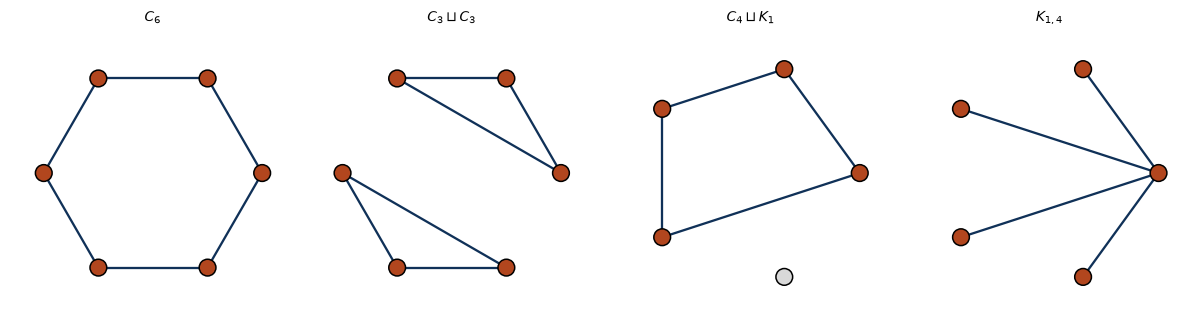

In [12]:
def small_graph(edges, n=N_NODES):
    """A named small graph, padded with isolated vertices to the same input size."""
    A = np.zeros((n, n), np.float32)
    for i, j in edges:
        A[i, j] = A[j, i] = 1
    return A


C6 = small_graph([(0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 0)])     # one 6-cycle
C3C3 = small_graph([(0, 1), (1, 2), (2, 0), (3, 4), (4, 5), (5, 3)])   # two triangles
C4K1 = small_graph([(0, 1), (1, 2), (2, 3), (3, 0)])                   # 4-cycle + a point
K14 = small_graph([(0, 1), (0, 2), (0, 3), (0, 4)])                    # the star

spec = lambda A: np.sort(np.linalg.eigvalsh(A))
tri = lambda A: np.trace(A @ A @ A) / 6
with torch.no_grad():
    emb = lambda A: g_mp.nodes(torch.tensor(flat(A[None]))).sum(1).numpy().ravel()

    print(f"  {'pair':24s}{'triangles':>12s}{'spectra differ':>17s}"
          f"{'embeddings differ':>20s}")
    for name, P, Q in [("C_6  vs  C_3 + C_3", C6, C3C3),
                       ("C_4 + K_1  vs  K_1,4", C4K1, K14)]:
        print(f"  {name:24s}{f'{tri(P):.0f} vs {tri(Q):.0f}':>12s}"
              f"{np.abs(spec(P) - spec(Q)).max():17.2e}"
              f"{np.abs(emb(P) - emb(Q)).max():20.2e}")


def draw_graph(ax, A, title):
    """Circular layout; isolated (degree-0) nodes drawn in grey."""
    n = A.shape[0]
    theta = np.linspace(0, 2 * np.pi, n, endpoint=False)
    pos = np.stack([np.cos(theta), np.sin(theta)], axis=1)
    for i, j in zip(*np.triu_indices(n, 1)):
        if A[i, j]:
            ax.plot(*pos[[i, j]].T, color=GEO_DARK, lw=1.5, zorder=1)
    colors = [GEO_RUST if d > 0 else "0.85" for d in A.sum(1)]
    ax.scatter(*pos.T, s=120, color=colors, edgecolor="k", zorder=2)
    ax.set_title(f"${title}$", fontsize=9)
    ax.set_xlim(-1.3, 1.3); ax.set_ylim(-1.3, 1.3)
    ax.set_aspect("equal"); ax.axis("off")


fig, axes = plt.subplots(1, 4, figsize=(11, 3))
graphs = [("C_6", C6, 6), ("C_3 \\sqcup C_3", C3C3, 6),
          ("C_4 \\sqcup K_1", C4K1, 5), ("K_{1,4}", K14, 5)]
for ax, (name, A, n_active) in zip(axes, graphs):
    draw_graph(ax, A[:n_active, :n_active], name)
plt.tight_layout(); plt.show()

Message passing lands between the two, and where it lands is the interesting part.

It is exactly permutation-invariant — the check above holds to float32 precision, for
every relabelling rather than the ones we thought to try — and with *fewer*
parameters than the raw MLP it cuts that model's error by well over half. But it
loses to the spectrum by a factor of nearly seven, and that is not a matter of
tuning. Two theorems are at work, one in each direction, and the
last cell exhibits both.

**The spectrum can do something message passing cannot.** The label is
$\tfrac16\operatorname{tr}(A^3) = \tfrac16\sum_i \lambda_i^3$ — a *formula* in the
eigenvalues, so the spectral model is handed the answer and need only learn a cubic.
Message passing of this kind is exactly as discriminating as Weisfeiler–Leman colour
refinement, and WL cannot count triangles. The cell shows the cleanest instance:
$C_6$ and $C_3 \sqcup C_3$ are both $2$-regular, so every vertex receives the same
colour in both graphs at every round, and the two graphs receive **identical**
embeddings — the printed difference is exactly $0$, not merely small — while their
triangle counts are $0$ and $2$.

**And message passing can do something the spectrum cannot.** $C_4 \sqcup K_1$ and the
star $K_{1,4}$ are cospectral, the smallest such pair, so the spectral descriptor
sends them to the *same point* and no model built on it can ever separate them. Their
degree sequences differ, so message passing tells them apart in a single round.

So the two are **incomparable**: neither refines the other. That is worth stating
carefully, because it is often said loosely that equivariant architectures are
strictly more expressive than spectral descriptors, and on these two graphs that is
simply false.

That contrast is the practical content of Lecture 10, and it is sharper than a
ranking. Every strategy has a blind spot; the question is not which method is
strongest but **which incompleteness you can afford for the label you actually have**.
Here the label is a spectral formula, so the spectrum wins by a mile. Choose a label
that depends on local degree structure instead and the ordering should reverse —
which is Exercise 2(c), and worth doing, because the reversal is the whole lesson.

> **Exercise 2 — completeness, tested.**
> (a) The cell above shows the *descriptors* coincide on the cospectral pair. Turn
> that into a statement about *learning*: build a training set containing both members
> with different labels and show the spectral model's loss cannot fall below a floor
> you can compute in advance, while message passing fits it.
>
> (b) Fix the blind spot. Give each node a local triangle count, $\tfrac12(A \odot
> A^2)\mathbf{1}$, as an input feature instead of the constant $1$, and re-measure.
> How much of the gap to the spectrum closes, and why should you have expected that?
>
> (c) Find a label for which message passing beats the spectrum, and confirm it. A
> label that the degree sequence determines but the spectrum does not is the place to
> look.
>
> (d) Both descriptors are cheap. What would you use if you could afford only one and
> did not know the label in advance?

---
## 5. What to take away

- **Three strategies, one framework — and all three measured here.** Augmentation,
  invariant descriptors, and equivariant architectures are the complete list of ways
  to make a model respect a group action, and they trade off samples, mathematical
  effort, and design freedom.
- **Augmentation works and is not free.** It is approximate, it costs capacity and
  convergence speed, and it only covers the transformations you thought to apply.
- **An equivariant architecture buys exactness, not feature extraction.** On the point
  clouds it beat both the raw network and augmentation at the same budget and was
  invariant to machine precision before training began — yet three hand-computed
  eigenvalues still beat it eightfold, and the same MLP given the *complete* invariant
  in raw form (the whole Gram matrix) did worse than any of them. Symmetry constrains
  the hypothesis space; it does not do your nonlinear algebra.
- **Invariants are free symmetry when you can find them** — and finding them is
  mathematics, which is where a geometer has the advantage over a practitioner with
  more GPUs.
- **Sample efficiency is where symmetry pays.** The gap is widest exactly where data
  is scarce, which is the regime that mathematical datasets usually occupy.
- **Ask whether your invariant is complete, and what it is complete *for*.** The
  covariance spectrum is complete for $O(3)$ acting on point clouds; the adjacency
  spectrum is *not* complete for $S_n$ acting on graphs. Nor is message passing a
  strict improvement on it — §4 exhibits one pair of graphs that only the spectrum
  separates and one that only message passing separates, so the two are
  **incomparable**. What the descriptor forgets, the model can never learn.

### Next

**Lecture 11** continues into manifolds, spectral methods and diffusion models;
**Lectures 12–13** turn to PINNs, where the geometry enters through the differential
operator rather than the architecture. The mini-project begins in week 7 — and a
symmetry analysis of whatever data you choose is usually the highest-value hour you
can spend on it.

### Further reading

- Bronstein, Bruna, Cohen & Veličković, *Geometric Deep Learning: Grids, Groups, Graphs, Geodesics and Gauges* (2021) — the blueprint this whole tutorial follows.
- Cohen & Welling, "Group equivariant convolutional networks", *ICML* 2016.
- Villar et al., "Scalars are universal: equivariant machine learning, structured like classical physics", *NeurIPS* 2021 — the completeness question of §2 and §4, done properly.
- Xu et al., "How powerful are graph neural networks?", *ICLR* 2019 — the expressivity limits behind Exercise 2.
- Chen, Villar, Chen & Bruna, "Can graph neural networks count substructures?", *NeurIPS* 2020 — why §4's message-passing model cannot count triangles.